# 2D FEP Subtraction — Static Trial Background Comparison
### SSA — Diamond I11 Beamline | Static Trial (50mm)

**Purpose:** Now that the 50/100/200mm geometries are calibrated, this notebook:
1. Loads the real (calibrated) beam centre and re-derives the FEP ring radius
2. Builds three background candidates from the static trial data: `FEP_empty`, `Water_tri`, `EtOH_tri`
3. Subtracts each candidate from confirmed crystal-hit frames in `Gly_AS_tri`
4. Compares the three quantitatively to decide which background is best for glycine

---
**Run cells one at a time. Step 5 needs Step 3 and Step 4 to have completed first.**

---
## Step 0 — Paths and imports

In [1]:
import os, glob
import numpy as np
import pandas as pd

# ══════════════════════════════════════════════════════════════
# PATHS — confirm/update these before running
# ══════════════════════════════════════════════════════════════

MODULE_DIR   = r"C:/Users/ezxsa27/I11_PXRD_SSA/I11_PXRD_processing_scripts/FEP_Subtraction/"   # <-- FIXED: folder, not the .py file itself
import sys
sys.path.insert(0, MODULE_DIR)

RAW_ROOT     = r"E:/static/raw/raw_D1+2/"                   # <-- update: single folder holding ALL raw static-trial files
OUTPUT_DIR   = r"E:/static/Corrected_2D/Trial_BG_Comparison/"  # <-- update
PONI_50MM    = r"E:/static/raw/Calib/Calib_50_poni.poni"           # <-- update: your validated 50mm poni
MASK_PATH    = r"E:/static/raw/Calib/Calib_50_mask.npy"             # <-- update: mask for THIS geometry, not X2_mask.npy
TRACKER_PATH = r"C:/Users/ezxsa27/OneDrive - The University of Nottingham/Nottingham/Year 3 (June 26 -)/Static Trials/I11_Static_Trials_Tracker_CLEAN.xlsx"  # <-- update: your tracker spreadsheet

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ══════════════════════════════════════════════════════════════
# Read collection numbers straight from the tracker — no manual
# file sorting needed. Row 5 (1-indexed) holds the real headers,
# so header=4 (0-indexed) below.
# ══════════════════════════════════════════════════════════════

tracker = pd.read_excel(TRACKER_PATH, sheet_name="Condition Tracker", header=6)
tracker.columns = [str(c).strip() for c in tracker.columns]
tracker["Sample code"]   = tracker["Sample code"].astype(str).str.strip()
tracker["Exposure code"] = tracker["Exposure code"].astype(str).str.strip()
tracker["Data logged?"]  = tracker["Data logged?"].astype(str).str.strip().str.upper()

# Respect the Exclude? flag, and use "Data logged?" (collection # present),
# NOT the original "Collected?" column — the dashboard flagged CBZ_AS_tri
# rows that say Y but have no real collection number.
tracker_clean = tracker[
    (tracker["Data logged?"] == "Y") &
    (tracker["Exclude?"].isna())
]

def collection_numbers_for(sample_code, distance=50, exposure_code=None):
    sub = tracker_clean[
        (tracker_clean["Sample code"] == sample_code) &
        (tracker_clean["Distance (mm)"] == distance)
    ]
    if exposure_code is not None:
        sub = sub[sub["Exposure code"] == exposure_code]
    return sub["Collection #(s)"].dropna().astype(int).astype(str).tolist()

# tracker_50: 50mm-only slice, kept as a named variable since the SNR sweep
# and Swish-comparison cells below group directly off it.
tracker_50 = tracker_clean[tracker_clean["Distance (mm)"] == 50]

FEP_EMPTY_NUMBERS = collection_numbers_for("FEP_empty")
WATER_TRI_NUMBERS = collection_numbers_for("Water_tri")
ETOH_TRI_NUMBERS  = collection_numbers_for("EtOH_tri")
GLY_AS_NUMBERS    = collection_numbers_for("Gly_AS_tri")

print(f"FEP_empty : {len(FEP_EMPTY_NUMBERS)} collection numbers (from tracker)")
print(f"Water_tri : {len(WATER_TRI_NUMBERS)} collection numbers (from tracker)")
print(f"EtOH_tri  : {len(ETOH_TRI_NUMBERS)} collection numbers (from tracker)")
print(f"Gly_AS_tri: {len(GLY_AS_NUMBERS)} collection numbers (from tracker)")

# ══════════════════════════════════════════════════════════════
# Match tracker collection numbers to actual raw files. Raw files
# can all sit in ONE flat folder (RAW_ROOT) - no need to pre-sort
# them into per-condition subfolders.
# ══════════════════════════════════════════════════════════════
def extract_number(fp):
    stem = os.path.splitext(os.path.basename(fp))[0]
    for part in reversed(stem.replace("-", "_").split("_")):
        if part.isdigit():
            return part
    return ""

all_raw_files = sorted(glob.glob(os.path.join(RAW_ROOT, "*.nxs")))
if not all_raw_files:
    all_raw_files = sorted(glob.glob(os.path.join(RAW_ROOT, "*.hdf")))
    print(f"\nUsing .hdf files: {len(all_raw_files)} found in RAW_ROOT")
else:
    print(f"\nUsing .nxs files: {len(all_raw_files)} found in RAW_ROOT")

all_numbers = {f: extract_number(f) for f in all_raw_files}

def files_for_numbers(numbers):
    wanted = set(numbers)
    return sorted([f for f, n in all_numbers.items() if n in wanted])

FEP_EMPTY_FILES = files_for_numbers(FEP_EMPTY_NUMBERS)
WATER_TRI_FILES = files_for_numbers(WATER_TRI_NUMBERS)
ETOH_TRI_FILES  = files_for_numbers(ETOH_TRI_NUMBERS)
GLY_AS_FILES    = files_for_numbers(GLY_AS_NUMBERS)

print(f"\nMatched to raw files:")
print(f"FEP_empty : {len(FEP_EMPTY_FILES)} / {len(FEP_EMPTY_NUMBERS)} tracker numbers matched")
print(f"Water_tri : {len(WATER_TRI_FILES)} / {len(WATER_TRI_NUMBERS)} tracker numbers matched")
print(f"EtOH_tri  : {len(ETOH_TRI_FILES)} / {len(ETOH_TRI_NUMBERS)} tracker numbers matched")
print(f"Gly_AS_tri: {len(GLY_AS_FILES)} / {len(GLY_AS_NUMBERS)} tracker numbers matched")

all_number_sets = [FEP_EMPTY_NUMBERS, WATER_TRI_NUMBERS, ETOH_TRI_NUMBERS, GLY_AS_NUMBERS]
all_file_sets   = [FEP_EMPTY_FILES, WATER_TRI_FILES, ETOH_TRI_FILES, GLY_AS_FILES]
if any(len(files) < len(nums) for files, nums in zip(all_file_sets, all_number_sets)):
    print("\n⚠️  Some tracker collection numbers were not found among raw files.")
    print("   Check RAW_ROOT and the file extension/naming pattern above.")
else:
    print("\n✅ All tracked collection numbers matched to raw files. Continue to Step 1.")

FEP_empty : 17 collection numbers (from tracker)
Water_tri : 25 collection numbers (from tracker)
EtOH_tri  : 19 collection numbers (from tracker)
Gly_AS_tri: 37 collection numbers (from tracker)

Using .nxs files: 199 found in RAW_ROOT

Matched to raw files:
FEP_empty : 16 / 17 tracker numbers matched
Water_tri : 25 / 25 tracker numbers matched
EtOH_tri  : 19 / 19 tracker numbers matched
Gly_AS_tri: 36 / 37 tracker numbers matched

⚠️  Some tracker collection numbers were not found among raw files.
   Check RAW_ROOT and the file extension/naming pattern above.


In [3]:
from collections import Counter
print("FEP_empty duplicate collection numbers:", [n for n, c in Counter(FEP_EMPTY_NUMBERS).items() if c > 1])
print("Gly_AS_tri duplicate collection numbers:", [n for n, c in Counter(GLY_AS_NUMBERS).items() if c > 1])

FEP_empty duplicate collection numbers: ['145358']
Gly_AS_tri duplicate collection numbers: ['145296']


In [4]:
from fep_subtraction_2d_i11 import (
    beam_center_px_from_poni,
    FrameMetricConfig,
    evaluate_frame_with_status,
    classify_dataset,
    _load_pixium_frame,
    subtract_fep_2d,
    inspect_nexus,
)
print("✅ Module imported.")

✅ Module imported.


---
## Step 1 — Load calibrated beam centre

Reads the real beam centre from your validated `calib_50mm.poni`. This replaces the old hardcoded frame-midpoint assumption everywhere downstream.

In [5]:
cy, cx = beam_center_px_from_poni(PONI_50MM)
print(f"Calibrated beam centre: row(cy)={cy:.2f}px  col(cx)={cx:.2f}px")

mask = np.load(MASK_PATH)
print(f"Mask loaded: {mask.shape}  masked pixels: {mask.sum():,} ({100*mask.sum()/mask.size:.1f}%)")

# Base config carrying the calibrated centre through everything below.
# detect_fep_ring=True so we don't reuse the old uncalibrated r~255px value.
cfg = FrameMetricConfig(
    beam_center_px=(cy, cx),
    detect_fep_ring=True,
)

Calibrated beam centre: row(cy)=1442.20px  col(cx)=1441.66px
Mask loaded: (2881, 2880)  masked pixels: 54,394 (0.7%)


---
## Step 2 — Re-derive the FEP ring radius at the corrected centre

The old r≈255px value was measured under the uncalibrated (frame-midpoint) geometry. Run this on one `FEP_empty` frame to get the real ring radius for this geometry.

In [6]:
inspect_nexus(FEP_EMPTY_FILES[0])

metrics, status = evaluate_frame_with_status(
    FEP_EMPTY_FILES[0],
    mask=mask,
    config=cfg,
)

print(f"\nStatus: {status.status}")
print(f"New FEP ring radius: {status.fep_ring_r} px  (old assumed value was 255px)")

# Lock this in as a fixed value for consistency across all frames in this trial,
# rather than re-detecting per-frame (small frame-to-frame noise can jitter the
# detected peak slightly — fixing it keeps all comparisons on the same footing).
cfg = FrameMetricConfig(
    beam_center_px=(cy, cx),
    detect_fep_ring=False,
    fixed_fep_ring_r=status.fep_ring_r,
)
print(f"\ncfg updated with fixed_fep_ring_r={cfg.fixed_fep_ring_r}")


  i11-1-145262.nxs
  D entry1  [NXentry]
      D entry1/before_scan  [NXcollection]
            entry1/before_scan/pixium10_BaseExposure   shape=(1,)  dtype=float64
            entry1/before_scan/pixium10_ExcludeEarlyFrames   shape=(1,)  dtype=object
            entry1/before_scan/pixium10_PUMode   shape=(1,)  dtype=float64
            entry1/before_scan/pixium10_TotalCount   shape=(1,)  dtype=float64
            entry1/before_scan/pixium10_TriggerMode   shape=(1,)  dtype=object
      D entry1/calibrant  [NXsample]
            entry1/calibrant/name   shape=(1,)  dtype=object
        entry1/end_time   shape=()  dtype=object
        entry1/entry_identifier   shape=()  dtype=object
        entry1/experiment_identifier   shape=()  dtype=object
      D entry1/instrument  [NXinstrument]
          D entry1/instrument/ds  [NXpositioner]
                entry1/instrument/ds/ds   shape=(1,)  dtype=float64
                entry1/instrument/ds/soft_limit_max   shape=(1,)  dtype=float64
          

---
## Step 2b — Which exposure/technique gives the best SNR?

Uses `FEP_empty` as the test bed (cleanest signal — no solvent or crystal confound). Compares every exposure duration using the **real** exposure time read from each frame's NeXus metadata, plus the Swish technique (averaged short repeats) vs single continuous exposures.

**SNR definition:** peak FEP-ring signal (radial mean at the calibrated ring radius) ÷ residual noise (MAD-based sigma of the diffuse background after radial subtraction). Also reported per √(exposure time), since raw SNR trivially improves with longer exposure.

In [7]:
from fep_subtraction_2d_i11 import _read_exposure_time, _mad_sigma

RING_HALFWIDTH = 15   # px either side of cfg.fixed_fep_ring_r to average as 'signal'

def frame_snr(filepaths, beam_center_px, ring_r, mask,
              beam_excl=60, outer_excl=1200, ring_halfwidth=RING_HALFWIDTH):
    """
    Compute peak/noise SNR for one or more frames (averaged if multiple -
    e.g. a Swish group). Returns signal, noise, snr, and total exposure
    time (summed across all frames passed in, from NeXus metadata).
    """
    stack = []
    total_time = 0.0
    for fp in filepaths:
        frame = _load_pixium_frame(fp)
        if frame.ndim == 3:
            frame = frame[0]
        stack.append(frame.astype(np.float64))
        t = _read_exposure_time(fp)
        total_time += t if t else 0.0

    arr = np.mean(stack, axis=0)
    arr[mask.astype(bool)] = 0.0

    rows, cols = arr.shape
    cy, cx = beam_center_px
    y_idx, x_idx = np.ogrid[:rows, :cols]
    r_map = np.sqrt((x_idx - cx) ** 2 + (y_idx - cy) ** 2).astype(np.int32)
    r_max = int(r_map.max())

    radial_sum = np.bincount(r_map.ravel(), weights=arr.ravel(), minlength=r_max + 1)
    radial_cnt = np.bincount(r_map.ravel(), minlength=r_max + 1)
    with np.errstate(invalid="ignore", divide="ignore"):
        radial_mean = np.where(radial_cnt > 0, radial_sum / radial_cnt, 0.0)

    # Signal: radial-mean intensity in the FEP ring annulus
    lo, hi = max(0, ring_r - ring_halfwidth), min(r_max, ring_r + ring_halfwidth)
    signal = float(np.mean(radial_mean[lo:hi + 1]))

    # Noise: MAD-based sigma of the residual, in the diffuse region,
    # EXCLUDING the ring annulus itself (so noise reflects background
    # flatness, not the peak we just measured)
    residual = arr - radial_mean[r_map]
    detection_mask = (r_map >= beam_excl) & (r_map <= outer_excl)
    detection_mask &= ~((r_map >= lo) & (r_map <= hi))
    detection_mask &= ~mask.astype(bool)
    noise = _mad_sigma(residual[detection_mask])

    snr = signal / noise if noise > 0 else float("nan")
    return {
        "signal": signal, "noise": noise, "snr": snr,
        "total_time_s": total_time, "n_frames": len(stack),
        "snr_per_sqrt_time": snr / np.sqrt(total_time) if total_time > 0 else float("nan"),
    }

print("Helper defined.")

Helper defined.


In [8]:
import h5py

def _read_exposure_time(filepath):
    """Override: static trial files use 'pixium_hdf' as the detector group name."""
    paths = [
        "entry1/instrument/pixium_hdf/count_time",
        "entry/instrument/pixium_hdf/count_time",
        "entry1/instrument/detector/count_time",
        "entry1/instrument/detector/exposure_time",
        "entry/instrument/detector/count_time",
        "entry/instrument/detector/exposure_time",
        "entry1/count_time",
        "entry/count_time",
    ]
    with h5py.File(filepath, "r") as f:
        for p in paths:
            if p in f:
                val = np.squeeze(f[p][()])
                if val.ndim == 0:
                    return float(val)
                # Multiple sub-exposure times stored (e.g. an internally
                # accumulated multi-shot file) — sum them, since that's
                # the real total exposure represented by the single
                # stored frame.
                return float(np.sum(val))
    return None

In [9]:
fep_rows = tracker_50[
    (tracker_50["Sample code"] == "FEP_empty") &
    (~tracker_50["Exposure code"].str.contains("snapshot with swish", na=False))
].copy()

results = []

for exposure_code, group in fep_rows.groupby("Exposure code"):
    numbers = group["Collection #(s)"].dropna().astype(int).astype(str).tolist()
    files = files_for_numbers(numbers)
    if not files:
        print(f"⚠️  No files matched for exposure_code={exposure_code!r} — skipping")
        continue

    if exposure_code == "Swish":
        # One combined entry: all swish frames averaged together
        r = frame_snr(files, (cy, cx), cfg.fixed_fep_ring_r, mask)
        r["label"] = f"Swish (n={len(files)} frames averaged)"
        results.append(r)
    else:
        # Each file evaluated separately — naturally splits the two
        # different 'long' durations (30s/60s) since real exposure
        # times differ even though the tracker label is the same.
        for fp in files:
            r = frame_snr([fp], (cy, cx), cfg.fixed_fep_ring_r, mask)
            r["label"] = f"{exposure_code} ({os.path.basename(fp)}, {r['total_time_s']:.2f}s measured)"
            results.append(r)

results.sort(key=lambda r: r["snr_per_sqrt_time"], reverse=True)

print(f"{'Technique':<45} {'time(s)':>8} {'signal':>10} {'noise':>8} {'SNR':>8} {'SNR/√t':>8}")
print("-" * 92)
for r in results:
    print(f"{r['label']:<45} {r['total_time_s']:>8.2f} {r['signal']:>10.1f} "
          f"{r['noise']:>8.3f} {r['snr']:>8.2f} {r['snr_per_sqrt_time']:>8.3f}")

print("\nHighest raw SNR   :", max(results, key=lambda r: r['snr'])['label'])
print("Most efficient (SNR/√t):", max(results, key=lambda r: r['snr_per_sqrt_time'])['label'])

Technique                                      time(s)     signal    noise      SNR   SNR/√t
--------------------------------------------------------------------------------------------
1000ms (i11-1-145266.nxs, 1.00s measured)         1.00      277.4    4.554    60.91   60.909
2-3s (i11-1-145264.nxs, 3.00s measured)           3.00      847.3    9.806    86.40   49.883
250ms (i11-1-145269.nxs, 0.25s measured)          0.25       91.7    3.754    24.42   48.843
500ms (i11-1-145268.nxs, 0.50s measured)          0.50      184.9    5.525    33.47   47.331
Swish (n=3 frames averaged)                       7.00      879.0   13.259    66.30   25.057
long (i11-1-145263.nxs, 30.00s measured)         30.00     8313.8   72.839   114.14   20.839
long (i11-1-145262.nxs, 60.00s measured)         60.00    16651.6  143.101   116.36   15.022

Highest raw SNR   : long (i11-1-145262.nxs, 60.00s measured)
Most efficient (SNR/√t): 1000ms (i11-1-145266.nxs, 1.00s measured)


### Swish VS Snapshot weighting

In [ ]:
gly_rows = tracker_50[tracker_50["Sample code"] == "Gly_AS_tri"].copy()

spot_results = []

for exposure_code, group in gly_rows.groupby("Exposure code"):
    numbers = group["Collection #(s)"].dropna().astype(int).astype(str).tolist()
    files = files_for_numbers(numbers)
    if not files:
        print(f"⚠️  No files matched for exposure_code={exposure_code!r} — skipping")
        continue

    for fp in files:
        metrics, status = evaluate_frame_with_status(fp, mask=mask, config=cfg)
        if status.status != "ok":
            print(f"  skipped {os.path.basename(fp)}: {status.error}")
            continue
        spot_results.append({
            "exposure_code": exposure_code,
            "file": os.path.basename(fp),
            "spot_density": status.spot_density,
            "crystal_score": status.crystal_score,
            "auto_class": status.auto_class,
            "exposure_time_s": _read_exposure_time(fp),
        })

import pandas as pd
df_spot = pd.DataFrame(spot_results)
print(df_spot[["exposure_code", "file", "exposure_time_s", "spot_density", "crystal_score", "auto_class"]]
      .sort_values("exposure_code").to_string(index=False))

In [ ]:
summary = df_spot.groupby("exposure_code").agg(
    n_frames=("spot_density", "size"),
    mean_spot_density=("spot_density", "mean"),
    max_spot_density=("spot_density", "max"),
    n_classified_crystal=("auto_class", lambda s: (s == "crystal").sum()),
    total_time_s=("exposure_time_s", "sum"),
).sort_values("mean_spot_density", ascending=False)

print(summary)

print(
    "\nCAVEAT: 'Swish' here moves the stage across a STATIC tri-segmented sample "
    "(sampling different slugs), not tracking one continuously flowing slug. This "
    "can only show whether stage movement helps catch crystal signal in this test "
    "rig — it does not validate or rule out the real-flow tracking rationale, which "
    "depends on continuous alignment with one moving slug at flow speed."
)

---
## Step 3 — Build the three background candidates

None of `FEP_empty`, `Water_tri`, `EtOH_tri` contain crystals, so there's no classification step here — just averaging repeats at a matching exposure time to reduce noise.

**Update `EXPOSURE_LABEL` / file selection below to match whichever exposure time you're comparing against in Gly_AS_tri** (e.g. if your Gly_AS_tri test frame was a 100ms snapshot, average the 100ms repeats from each condition, not a mismatched exposure).

In [10]:
# Narrow to the 1s exposure — the setting the SNR sweep found most
# efficient, and the one you're already running operationally.
# NOTE: the clean tracker uses the REAL exposure duration as the code
# now ("1000ms"), not the old legacy "100ms" label — using the old
# label here would silently match zero files.
EXPOSURE_CODE = "1000ms"

FEP_EMPTY_NUMBERS_100ms = collection_numbers_for("FEP_empty", exposure_code=EXPOSURE_CODE)
WATER_TRI_NUMBERS_100ms = collection_numbers_for("Water_tri", exposure_code=EXPOSURE_CODE)
ETOH_TRI_NUMBERS_100ms  = collection_numbers_for("EtOH_tri",  exposure_code=EXPOSURE_CODE)

FEP_EMPTY_FILES_100ms = files_for_numbers(FEP_EMPTY_NUMBERS_100ms)
WATER_TRI_FILES_100ms = files_for_numbers(WATER_TRI_NUMBERS_100ms)
ETOH_TRI_FILES_100ms  = files_for_numbers(ETOH_TRI_NUMBERS_100ms)

print(f"FEP_empty @ {EXPOSURE_CODE}: {len(FEP_EMPTY_FILES_100ms)} file(s)")
print(f"Water_tri @ {EXPOSURE_CODE}: {len(WATER_TRI_FILES_100ms)} file(s)")
print(f"EtOH_tri  @ {EXPOSURE_CODE}: {len(ETOH_TRI_FILES_100ms)} file(s)")

FEP_empty @ 1000ms: 1 file(s)
Water_tri @ 1000ms: 7 file(s)
EtOH_tri  @ 1000ms: 5 file(s)


In [11]:
def average_frames(filepaths, label=""):
    """Average a list of raw frames into a single background candidate."""
    stack = []
    for fp in filepaths:
        frame = _load_pixium_frame(fp)
        if frame.ndim == 3:
            frame = frame[0]
        stack.append(frame.astype(np.float64))
    bg = np.mean(stack, axis=0)
    print(f"{label}: {len(stack)} frames averaged (noise / sqrt({len(stack)}) = {1/np.sqrt(len(stack)):.3f})")
    return bg

# ══════════════════════════════════════════════════════════════
# UPDATE: filter each list down to the exposure time you want to
# compare against, e.g. by filename pattern or a manual index slice.
# Using ALL files here as a placeholder — narrow this down first.
# ══════════════════════════════════════════════════════════════
fep_empty_bg = average_frames(FEP_EMPTY_FILES_100ms, "FEP_empty background")
water_bg     = average_frames(WATER_TRI_FILES_100ms, "Water_tri background")
etoh_bg      = average_frames(ETOH_TRI_FILES_100ms,  "EtOH_tri background")

backgrounds = {
    "FEP_empty": fep_empty_bg,
    "Water_tri": water_bg,
    "EtOH_tri":  etoh_bg,
}
print("\n✅ Three background candidates built.")

FEP_empty background: 1 frames averaged (noise / sqrt(1) = 1.000)
Water_tri background: 7 frames averaged (noise / sqrt(7) = 0.378)
EtOH_tri background: 5 frames averaged (noise / sqrt(5) = 0.447)

✅ Three background candidates built.


In [12]:
fp_check = [f for f in WATER_TRI_FILES_100ms if "145275" in f][0]
frame_check = _load_pixium_frame(fp_check)
print("Shape:", frame_check.shape)

Shape: (1, 2881, 2880)


---
## Step 4 — Identify confirmed crystal-hit frames in Gly_AS_tri

Classify the Gly_AS_tri set using the corrected geometry, and confirm the frame(s) you already know contain crystals are flagged accordingly.

In [13]:
csv_path = os.path.join(OUTPUT_DIR, "gly_as_tri_classification.csv")

gly_metrics = classify_dataset(
    GLY_AS_FILES,
    mask=mask,
    config=cfg,
    csv_output=csv_path,
)

crystal_frames = [m for m in gly_metrics if m.auto_class == "crystal"]
print(f"\n{len(crystal_frames)} frame(s) auto-classified as crystal.")
for m in crystal_frames[:10]:
    print(f"  {os.path.basename(m.filepath)}  frame={m.frame_index}  score={m.crystal_score:.3f}")

# ══════════════════════════════════════════════════════════════
# Pick the test frame(s) to run the background comparison on.
# If you already know which collection number(s) are confirmed
# crystal hits from visual review, set them explicitly here instead
# of trusting auto-classification alone.
# ══════════════════════════════════════════════════════════════
TEST_FRAME = next(m for m in gly_metrics if "145298" in m.filepath)
print(f"Using test frame: {os.path.basename(TEST_FRAME.filepath)}  score={TEST_FRAME.crystal_score:.3f}  class={TEST_FRAME.auto_class}")

  Failed: i11-1-145401.nxs — No 2D dataset found in i11-1-145401.nxs. Pass detector_path explicitly.



────────────────────────────────────────────────────────────────
  Dataset classification  (51 frames from 36 files)
────────────────────────────────────────────────────────────────
  crystal        24 frames  ██████████████████
  solution        0 frames  
  gas             0 frames  
  uncertain      27 frames  █████████████████████
────────────────────────────────────────────────────────────────

  Top crystal candidates:
    score=1.000  i11-1-145293.nxs  frame=0
    score=1.000  i11-1-145294.nxs  frame=0
    score=1.000  i11-1-145295.nxs  frame=0
    score=1.000  i11-1-145296.nxs  frame=0
    score=1.000  i11-1-145297.nxs  frame=0
    score=1.000  i11-1-145298.nxs  frame=0
    score=1.000  i11-1-145299.nxs  frame=0
    score=1.000  i11-1-145300.nxs  frame=0
    score=1.000  i11-1-145302.nxs  frame=0
    score=1.000  i11-1-145303.nxs  frame=0

  ML training CSV: E:/static/Corrected_2D/Trial_BG_Comparison/gly_as_tri_classification.csv


24 frame(s) auto-classified as crystal.
  i11

In [16]:
import h5py

fp = [f for f in GLY_AS_FILES if "145401" in f][0]

def dump_all(name, obj):
    kind = "GROUP" if isinstance(obj, h5py.Group) else "DATASET"
    shape = getattr(obj, "shape", "")
    print(f"{kind:<8} {name:<50} {shape}")

with h5py.File(fp, "r") as f:
    print("Full structure of", fp)
    f.visititems(dump_all)

    print("\n--- Checking for external links specifically ---")
    def check_links(name, obj):
        pass
    # Walk manually to catch external links visititems can silently skip
    def walk(group, prefix=""):
        for key in group.keys():
            link = group.get(key, getlink=True)
            full_name = f"{prefix}/{key}"
            print(f"{full_name:<50} link type: {type(link).__name__}", 
                  f"-> target: {getattr(link, 'filename', '')}/{getattr(link, 'path', '')}" if isinstance(link, h5py.ExternalLink) else "")
            if isinstance(group[key], h5py.Group):
                walk(group[key], full_name)
    walk(f)

Full structure of E:/static/raw/raw_D1+2\i11-1-145401.nxs
GROUP    entry1                                             
GROUP    entry1/before_scan                                 
DATASET  entry1/before_scan/pixium10_BaseExposure           (1,)
DATASET  entry1/before_scan/pixium10_ExcludeEarlyFrames     (1,)
DATASET  entry1/before_scan/pixium10_PUMode                 (1,)
DATASET  entry1/before_scan/pixium10_TotalCount             (1,)
DATASET  entry1/before_scan/pixium10_TriggerMode            (1,)
GROUP    entry1/calibrant                                   
DATASET  entry1/calibrant/name                              (1,)
DATASET  entry1/end_time                                    ()
DATASET  entry1/entry_identifier                            ()
DATASET  entry1/experiment_identifier                       ()
GROUP    entry1/instrument                                  
GROUP    entry1/instrument/ds                               
DATASET  entry1/instrument/ds/ds                          

---
## Step 5 — Subtract each background candidate from the same test frame

Runs `subtract_fep_2d` three times against the same crystal frame — once per background candidate — so the only thing that differs between the three outputs is the background itself.

In [17]:
corrected_results = {}

for bg_name, bg_array in backgrounds.items():
    out_path = os.path.join(
        OUTPUT_DIR,
        f"{os.path.splitext(os.path.basename(TEST_FRAME.filepath))[0]}_bg_{bg_name}.nxs"
    )
    result = subtract_fep_2d(
        data_filepath        = TEST_FRAME.filepath,
        background            = bg_array,
        output_filepath       = out_path,
        background_type       = bg_name,
        n_background_frames   = len(FEP_EMPTY_FILES_100ms) if bg_name=="FEP_empty" else
                                 len(WATER_TRI_FILES_100ms) if bg_name=="Water_tri" else
                                 len(ETOH_TRI_FILES_100ms),
        frame_index           = TEST_FRAME.frame_index,
        scale_factor           = None,   # 1s vs 1s — should auto-resolve to ~1.0
        beam_center_px         = (cy, cx),
        clip_negative           = True,
    )
    corrected_results[bg_name] = result
    print(f"{bg_name}: scale={result.scale_factor:.4g}  -> {out_path}")

print("\n✅ Three corrected versions produced — one per background candidate.")

FEP_empty: scale=1  -> E:/static/Corrected_2D/Trial_BG_Comparison/i11-1-145298_bg_FEP_empty.nxs


41.9% negative pixels after subtraction. scale_factor may be too high, or background frames contain crystal signal.


Water_tri: scale=1  -> E:/static/Corrected_2D/Trial_BG_Comparison/i11-1-145298_bg_Water_tri.nxs


39.0% negative pixels after subtraction. scale_factor may be too high, or background frames contain crystal signal.


EtOH_tri: scale=1  -> E:/static/Corrected_2D/Trial_BG_Comparison/i11-1-145298_bg_EtOH_tri.nxs

✅ Three corrected versions produced — one per background candidate.


In [18]:
# Negative-pixel fraction for all three, not just the one that warned
for bg_name, result in corrected_results.items():
    corr = result.corrected_frame
    n_neg = int(np.sum(corr < 0))
    pct_neg = 100 * n_neg / corr.size
    print(f"{bg_name}: negative pixels = {pct_neg:.2f}%  mean corrected = {corr.mean():.1f}  min = {corr.min():.1f}")

print()

# Check raw intensity: is FEP_empty brighter than the sample frame itself?
raw_frame = _load_pixium_frame(TEST_FRAME.filepath, TEST_FRAME.frame_index)
if raw_frame.ndim == 3:
    raw_frame = raw_frame[0]
print(f"Raw Gly_AS_tri sample frame : mean={raw_frame.mean():.1f}  max={raw_frame.max():.0f}")
for bg_name, bg_array in backgrounds.items():
    print(f"{bg_name} background        : mean={bg_array.mean():.1f}  max={bg_array.max():.0f}")

FEP_empty: negative pixels = 0.00%  mean corrected = 15.8  min = 0.0
Water_tri: negative pixels = 0.00%  mean corrected = 4.4  min = 0.0
EtOH_tri: negative pixels = 0.00%  mean corrected = 5.4  min = 0.0

Raw Gly_AS_tri sample frame : mean=39.9  max=59482
FEP_empty background        : mean=24.2  max=639
Water_tri background        : mean=38.6  max=649
EtOH_tri background        : mean=38.0  max=739


In [21]:
print("Per-file raw means going into each background:")
for bg_name, files in [("FEP_empty", FEP_EMPTY_FILES_100ms),
                       ("Water_tri", WATER_TRI_FILES_100ms),
                       ("EtOH_tri",  ETOH_TRI_FILES_100ms)]:
    for fp in files:
        frame = _load_pixium_frame(fp)
        if frame.ndim == 3:
            frame = frame[0]
        print(f"  {bg_name:<10} {os.path.basename(fp)}  mean={frame.mean():.1f}")

Per-file raw means going into each background:
  FEP_empty  i11-1-145266.nxs  mean=24.2
  Water_tri  i11-1-145275.nxs  mean=48.7
  Water_tri  i11-1-145276.nxs  mean=40.9
  Water_tri  i11-1-145283.nxs  mean=27.1
  Water_tri  i11-1-145367.nxs  mean=38.2
  Water_tri  i11-1-145368.nxs  mean=37.9
  Water_tri  i11-1-145369.nxs  mean=37.9
  Water_tri  i11-1-145370.nxs  mean=39.8
  EtOH_tri   i11-1-145288.nxs  mean=43.6
  EtOH_tri   i11-1-145371.nxs  mean=36.5
  EtOH_tri   i11-1-145372.nxs  mean=36.6
  EtOH_tri   i11-1-145373.nxs  mean=36.6
  EtOH_tri   i11-1-145374.nxs  mean=36.7


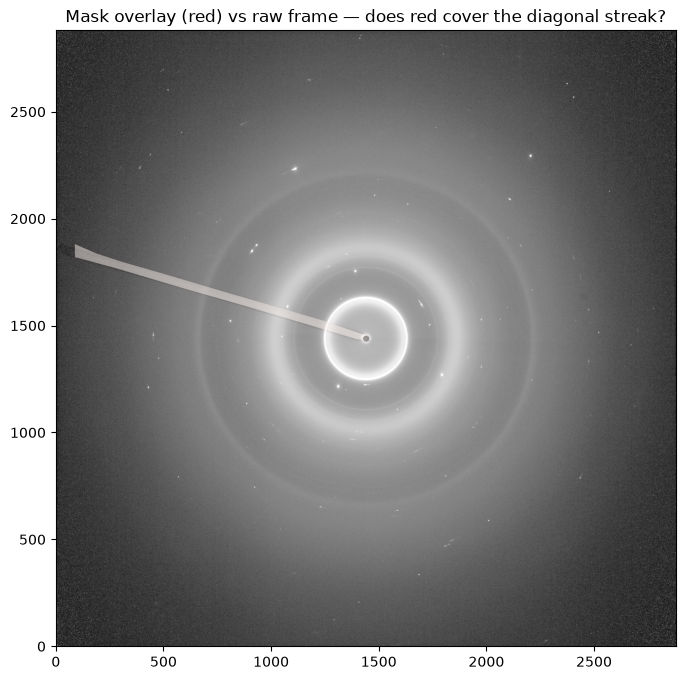

In [19]:
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt

# Self-contained: (re)computes display range from raw_frame directly,
# rather than assuming vmin/vmax/LogNorm already exist in the kernel.
vmin = max(1.0, float(np.percentile(raw_frame[raw_frame > 0], 1)))
vmax = float(np.percentile(raw_frame, 99.9))

#beamstop being masked?
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(raw_frame, origin="lower", norm=LogNorm(vmin=vmin, vmax=vmax), cmap="gray", aspect="auto")
ax.imshow(np.ma.masked_where(~mask.astype(bool), mask), origin="lower", cmap="Reds", alpha=0.5, aspect="auto")
ax.set_title("Mask overlay (red) vs raw frame — does red cover the diagonal streak?")
plt.show()


In [22]:
def best_fit_scale(raw, bg, valid_mask):
    """Least-squares optimal scale: minimises sum((raw - s*bg)^2) over valid_mask."""
    r = raw[valid_mask]
    b = bg[valid_mask]
    return float(np.sum(r * b) / np.sum(b * b))

# Use the same diffuse, non-spot, non-masked region as your noise metric
valid_mask = (~mask.astype(bool))

print(f"{'Background':<12} {'fitted scale':>13} {'% negative (fitted)':>20}")
print("-" * 50)
for bg_name, bg_array in backgrounds.items():
    s_fit = best_fit_scale(raw_frame, bg_array, valid_mask)
    corr_fit = raw_frame - s_fit * bg_array
    pct_neg_fit = 100 * np.sum(corr_fit < 0) / corr_fit.size
    print(f"{bg_name:<12} {s_fit:>13.3f} {pct_neg_fit:>19.2f}%")

Background    fitted scale  % negative (fitted)
--------------------------------------------------
FEP_empty            1.557               40.50%
Water_tri            1.056               52.53%
EtOH_tri             1.045               45.82%


In [23]:
def radial_bestfit_subtract(raw, bg, valid_mask, r_map, bin_width=40):
    """
    Fit an independent best-fit scale per radial annulus, rather than one
    global scale for the whole frame. Lets the ring and the diffuse
    baseline each get matched independently — a single global scalar
    can't do this if their relative proportions differ between the
    background candidate and the sample frame.
    """
    r_max = int(r_map.max())
    bins = np.arange(0, r_max + bin_width, bin_width)
    corrected = raw.copy()

    for lo, hi in zip(bins[:-1], bins[1:]):
        bin_mask = (r_map >= lo) & (r_map < hi) & valid_mask
        if bin_mask.sum() < 50:
            continue
        r_vals, b_vals = raw[bin_mask], bg[bin_mask]
        denom = np.sum(b_vals * b_vals)
        s = float(np.sum(r_vals * b_vals) / denom) if denom > 0 else 1.0
        corrected[bin_mask] = raw[bin_mask] - s * bg[bin_mask]

    return corrected

valid_mask = ~mask.astype(bool)
rows, cols = raw_frame.shape
y_idx, x_idx = np.ogrid[:rows, :cols]
r_map_full = np.sqrt((x_idx - cx) ** 2 + (y_idx - cy) ** 2).astype(np.int32)

print(f"{'Background':<12} {'% negative (radial best-fit)':>28}")
print("-" * 45)
for bg_name, bg_array in backgrounds.items():
    corr_radial = radial_bestfit_subtract(raw_frame, bg_array, valid_mask, r_map_full)
    pct_neg_radial = 100 * np.sum(corr_radial[valid_mask] < 0) / valid_mask.sum()
    print(f"{bg_name:<12} {pct_neg_radial:>27.2f}%")

Background   % negative (radial best-fit)
---------------------------------------------
FEP_empty                          41.95%
Water_tri                          49.40%
EtOH_tri                           46.64%


In [24]:
# diffuse_mask: away from the FEP ring and Bragg spots — same region
# used for the noise metric elsewhere. r_map_full, valid_mask already
# defined in the radial best-fit cell above.
diffuse_mask = (r_map_full >= 400) & (r_map_full <= 1200) & valid_mask

from fep_subtraction_2d_i11 import _mad_sigma

print(f"{'Background':<12} {'residual median':>16} {'MAD sigma':>12} {'plain mean':>12} {'plain std':>12}")
print("-" * 70)
for bg_name, bg_array in backgrounds.items():
    residual = raw_frame - 1.0 * bg_array
    vals = residual[diffuse_mask]
    med = np.median(vals)
    mad_sigma = _mad_sigma(vals)
    print(f"{bg_name:<12} {med:>16.3f} {mad_sigma:>12.3f} {vals.mean():>12.3f} {vals.std():>12.3f}")

Background    residual median    MAD sigma   plain mean    plain std
----------------------------------------------------------------------
FEP_empty              16.000        8.896       19.602      124.455
Water_tri               2.286        6.354        2.916      123.844
EtOH_tri                4.200        7.710        5.438      123.990


---
## Step 6 — Compare the three quantitatively

For each background candidate, measure:
- FEP ring peak reduction (%) via pyFAI integration
- Residual flatness in the diffuse-scatter region (away from Bragg spots)
- % negative pixels post-subtraction
- Whether spot_density on Bragg peaks stays intact (background shouldn't eat real signal)

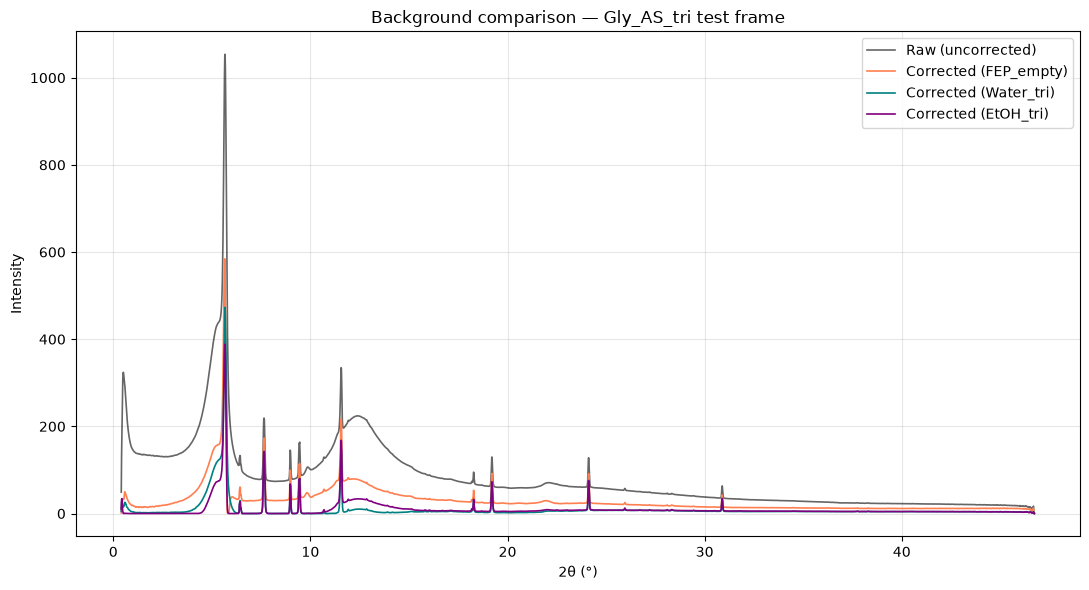


Background     FEP reduction   % negative px  scale_factor
------------------------------------------------------------
FEP_empty              44.5%           0.00%             1
Water_tri              55.1%           0.00%             1
EtOH_tri               63.1%           0.00%             1


In [25]:
%matplotlib inline
import matplotlib.pyplot as plt

try:
    import pyFAI
    ai = pyFAI.load(PONI_50MM)
    npt = 3000

    raw_frame = _load_pixium_frame(TEST_FRAME.filepath, TEST_FRAME.frame_index)
    if raw_frame.ndim == 3:
        raw_frame = raw_frame[0]
    mask_int = mask.astype(np.int32)
    tth_raw, i_raw = ai.integrate1d(raw_frame.astype(np.float32), npt, mask=mask_int, unit="2th_deg")

    fig, ax = plt.subplots(figsize=(11, 6))
    ax.plot(tth_raw, i_raw, lw=1.2, color="black", alpha=0.6, label="Raw (uncorrected)")

    colors = {"FEP_empty": "coral", "Water_tri": "teal", "EtOH_tri": "purple"}
    summary_rows = []

    for bg_name, result in corrected_results.items():
        corr = result.corrected_frame
        tth_c, i_c = ai.integrate1d(corr.astype(np.float32), npt, mask=mask_int, unit="2th_deg")
        ax.plot(tth_c, i_c, lw=1.2, color=colors[bg_name], label=f"Corrected ({bg_name})")

        # FEP ring reduction (adjust 2θ window if your ring sits elsewhere at this geometry)
        fep_lo, fep_hi = 5.4, 6.2
        m_raw  = (tth_raw >= fep_lo) & (tth_raw <= fep_hi)
        m_corr = (tth_c   >= fep_lo) & (tth_c   <= fep_hi)
        fep_raw_max  = i_raw[m_raw].max()
        fep_corr_max = i_c[m_corr].max()
        pct_reduction = 100 * (fep_raw_max - fep_corr_max) / fep_raw_max

        n_neg = int(np.sum(corr < 0))
        pct_neg = 100 * n_neg / corr.size

        summary_rows.append((bg_name, pct_reduction, pct_neg, result.scale_factor))

    ax.set_xlabel("2θ (°)"); ax.set_ylabel("Intensity")
    ax.set_title("Background comparison — Gly_AS_tri test frame")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "background_comparison_1D.png"), dpi=150)
    plt.show()

    print(f"\n{'Background':<12} {'FEP reduction':>15} {'% negative px':>15} {'scale_factor':>13}")
    print("-" * 60)
    for row in summary_rows:
        print(f"{row[0]:<12} {row[1]:>14.1f}% {row[2]:>14.2f}% {row[3]:>13.4g}")

except ImportError:
    print("pyFAI not available — install it to run this comparison.")

In [26]:
import plotly.graph_objects as go

fig = go.Figure()

offset_step = 150   # vertical gap between stacked traces — adjust to taste
colors = {"FEP_empty": "coral", "Water_tri": "teal", "EtOH_tri": "purple"}

# Raw on top, with true intensity preserved in hover via customdata
fig.add_trace(go.Scatter(
    x=tth_raw, y=i_raw + 3*offset_step, customdata=i_raw,
    name="Raw (uncorrected)", line=dict(color="gray", width=1),
    hovertemplate="2\u03b8=%{x:.2f}\u00b0<br>Intensity=%{customdata:.1f}<extra>Raw</extra>",
))

for i, (bg_name, result) in enumerate(corrected_results.items()):
    tth_c_i, i_c_i = ai.integrate1d(result.corrected_frame.astype(np.float32), npt,
                                     mask=mask.astype(np.int32), unit="2th_deg")
    fig.add_trace(go.Scatter(
        x=tth_c_i, y=i_c_i + (2 - i) * offset_step, customdata=i_c_i,
        name=f"Corrected ({bg_name})", line=dict(color=colors[bg_name], width=1.3),
        hovertemplate=f"2\u03b8=%{{x:.2f}}\u00b0<br>Intensity=%{{customdata:.1f}}<extra>{bg_name}</extra>",
    ))

fig.update_layout(
    title="Background comparison — stacked (Gly_AS_tri test frame)",
    xaxis_title="2\u03b8 (\u00b0)",
    yaxis=dict(title="Intensity (offset for clarity)", showticklabels=False),
    hovermode="x unified",
    height=700,
)
fig.show(renderer="browser")


In [27]:
# Step 1: rebuild Water_tri excluding the Day 1 air-bubble frame (145283) —
# flagged earlier as likely dragging the noise floor up more than genuine
# solvent physics would.
WATER_TRI_FILES_100ms_clean = [f for f in WATER_TRI_FILES_100ms if "145283" not in f]
print(f"Water_tri (bubble excluded): {len(WATER_TRI_FILES_100ms_clean)} files")

water_bg_clean = average_frames(WATER_TRI_FILES_100ms_clean, "Water_tri (bubble excluded)")

# Step 2: radially smooth it — the background should be azimuthally
# symmetric (no real angular structure, unlike a crystal frame), so
# averaging every pixel at a given radius uses far more samples per
# radius than just averaging 6 whole frames, without blurring away
# anything genuine.
rows, cols = water_bg_clean.shape
y_idx, x_idx = np.ogrid[:rows, :cols]
r_map_smooth = np.sqrt((x_idx - cx) ** 2 + (y_idx - cy) ** 2).astype(np.int32)
r_max_smooth = int(r_map_smooth.max())

radial_sum = np.bincount(r_map_smooth.ravel(), weights=water_bg_clean.ravel(), minlength=r_max_smooth + 1)
radial_cnt = np.bincount(r_map_smooth.ravel(), minlength=r_max_smooth + 1)
with np.errstate(invalid="ignore", divide="ignore"):
    radial_profile = np.where(radial_cnt > 0, radial_sum / radial_cnt, 0.0)

water_bg_smooth = radial_profile[r_map_smooth]
print("Radially-smoothed Water_tri background built.")

Water_tri (bubble excluded): 6 files
Water_tri (bubble excluded): 6 frames averaged (noise / sqrt(6) = 0.408)
Radially-smoothed Water_tri background built.


In [28]:
# Same MAD-robust check as before, but testing water_bg_smooth specifically
residual_smooth = raw_frame - 1.0 * water_bg_smooth
vals_smooth = residual_smooth[diffuse_mask]

med_smooth = np.median(vals_smooth)
mad_sigma_smooth = _mad_sigma(vals_smooth)

print(f"{'Background':<20} {'residual median':>16} {'MAD sigma':>12}")
print("-" * 50)
print(f"{'Water_tri (orig)':<20} {2.286:>16.3f} {6.354:>12.3f}")
print(f"{'Water_tri (clean+smooth)':<20} {med_smooth:>16.3f} {mad_sigma_smooth:>12.3f}")

Background            residual median    MAD sigma
--------------------------------------------------
Water_tri (orig)                2.286        6.354
Water_tri (clean+smooth)            0.325        5.956


In [29]:
# Use the improved, clean+radially-smoothed Water_tri as the production background
PRODUCTION_BACKGROUNDS = {"Water_tri_smooth": water_bg_smooth}
print("Production background set: Water_tri (bubble excluded, radially smoothed)")
print(f"Frames going into it: {len(WATER_TRI_FILES_100ms_clean)}")

Production background set: Water_tri (bubble excluded, radially smoothed)
Frames going into it: 6


In [31]:
FEP_WINDOW_LO, FEP_WINDOW_HI = 5.4, 6.0

production_results = []

for m in crystal_frames:   # from Step 4's classify_dataset() output
    fp = m.filepath
    frame_idx = m.frame_index

    row_result = {"file": os.path.basename(fp), "frame_index": frame_idx}

    for bg_name, bg_array in PRODUCTION_BACKGROUNDS.items():
        out_path = os.path.join(
            OUTPUT_DIR, "production",
            f"{os.path.splitext(os.path.basename(fp))[0]}_bg_{bg_name}.nxs"
        )
        result = subtract_fep_2d(
            data_filepath          = fp,
            background             = bg_array,
            output_filepath        = out_path,
            background_type        = bg_name,
            n_background_frames    = len(WATER_TRI_FILES_100ms_clean),
            frame_index             = frame_idx,
            scale_factor             = None,
            beam_center_px           = (cy, cx),
            clip_negative            = True,
        )

        tth_i, i_i = ai.integrate1d(result.corrected_frame.astype(np.float32), npt,
                                     mask=mask.astype(np.int32), unit="2th_deg")
        window = (tth_i >= FEP_WINDOW_LO) & (tth_i <= FEP_WINDOW_HI)
        row_result[f"{bg_name}_fep_window_max"] = float(i_i[window].max()) if window.any() else float("nan")
        row_result[f"{bg_name}_scale_factor"] = result.scale_factor
        row_result[f"{bg_name}_n_neg_pct"] = 100 * np.sum(result.corrected_frame < 0) / result.corrected_frame.size

    production_results.append(row_result)
    print(f"  done: {row_result['file']}")

df_production = pd.DataFrame(production_results)
df_production.to_csv(os.path.join(OUTPUT_DIR, "production_run_summary.csv"), index=False)
print(f"\n✅ Production pass complete: {len(df_production)} frames processed.")
print(df_production.to_string(index=False))

  done: i11-1-145293.nxs
  done: i11-1-145294.nxs
  done: i11-1-145295.nxs
  done: i11-1-145296.nxs
  done: i11-1-145297.nxs


  done: i11-1-145298.nxs


  done: i11-1-145299.nxs


  done: i11-1-145300.nxs
  done: i11-1-145302.nxs
  done: i11-1-145303.nxs
  done: i11-1-145304.nxs
  done: i11-1-145305.nxs
  done: i11-1-145306.nxs
  done: i11-1-145307.nxs
  done: i11-1-145308.nxs
  done: i11-1-145309.nxs
  done: i11-1-145310.nxs


  done: i11-1-145391.nxs


...

  done: i11-1-145393.nxs


  done: i11-1-145394.nxs


  done: i11-1-145402.nxs


  done: i11-1-145403.nxs


  done: i11-1-145404.nxs

✅ Production pass complete: 24 frames processed.
            file  frame_index  Water_tri_smooth_fep_window_max  Water_tri_smooth_scale_factor  Water_tri_smooth_n_neg_pct
i11-1-145293.nxs            0                     25036.269531                            1.0                         0.0
i11-1-145294.nxs            0                      2598.980957                            1.0                         0.0
i11-1-145295.nxs            0                      2660.764160                            1.0                         0.0
i11-1-145296.nxs            0                      2707.605225                            1.0                         0.0
i11-1-145297.nxs            0                     31296.445312                            1.0                         0.0
i11-1-145298.nxs            0                       602.783569                            1.0                         0.0
i11-1-145299.nxs            0                       252.688049         

In [32]:
FEP_WINDOW_LO, FEP_WINDOW_HI = 5.4, 6.0

median_results = []

for m in crystal_frames:
    fp = m.filepath
    stem = os.path.splitext(os.path.basename(fp))[0]
    out_path = os.path.join(OUTPUT_DIR, "production", f"{stem}_bg_Water_tri_smooth.nxs")

    corr = _load_pixium_frame(out_path)
    if corr.ndim == 3:
        corr = corr[0]

    tth_i, i_i = ai.integrate1d(corr.astype(np.float32), npt, mask=mask.astype(np.int32), unit="2th_deg")
    window = (tth_i >= FEP_WINDOW_LO) & (tth_i <= FEP_WINDOW_HI)

    median_results.append({
        "file": os.path.basename(fp),
        "fep_window_median": float(np.median(i_i[window])) if window.any() else float("nan"),
        "fep_window_p90": float(np.percentile(i_i[window], 90)) if window.any() else float("nan"),
        "fep_window_max": float(i_i[window].max()) if window.any() else float("nan"),
    })

df_median = pd.DataFrame(median_results)
print(df_median.to_string(index=False))

print("\nSummary across all 24 frames:")
print(df_median[["fep_window_median", "fep_window_p90", "fep_window_max"]].describe())

            file  fep_window_median  fep_window_p90  fep_window_max
i11-1-145293.nxs       13479.442383    23419.173828    25036.269531
i11-1-145294.nxs        1133.232666     2371.995850     2598.980957
i11-1-145295.nxs        1067.440430     2415.700928     2660.764160
i11-1-145296.nxs        1035.065430     2446.323975     2707.605225
i11-1-145297.nxs       13853.316406    28548.812500    31296.445312
i11-1-145298.nxs         101.290695      523.727905      602.783569
i11-1-145299.nxs           7.001724      204.777100      252.688049
i11-1-145300.nxs           0.000000        0.942722        2.994966
i11-1-145302.nxs         916.559937     2098.521484     2334.578613
i11-1-145303.nxs         827.350342     1501.071533     1597.743286
i11-1-145304.nxs         538.628418     1374.200684     1543.112427
i11-1-145305.nxs         481.345581      970.154114     1039.404419
i11-1-145306.nxs         462.195007     1135.505005     1271.233032
i11-1-145307.nxs         488.772156      990.104

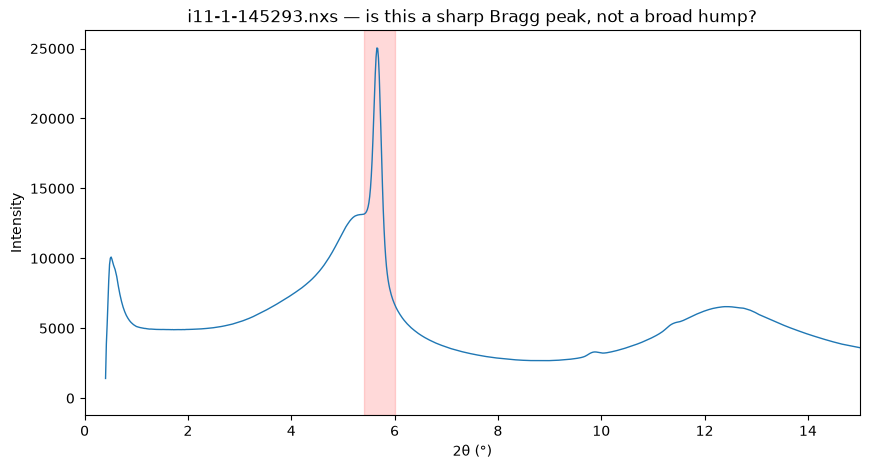

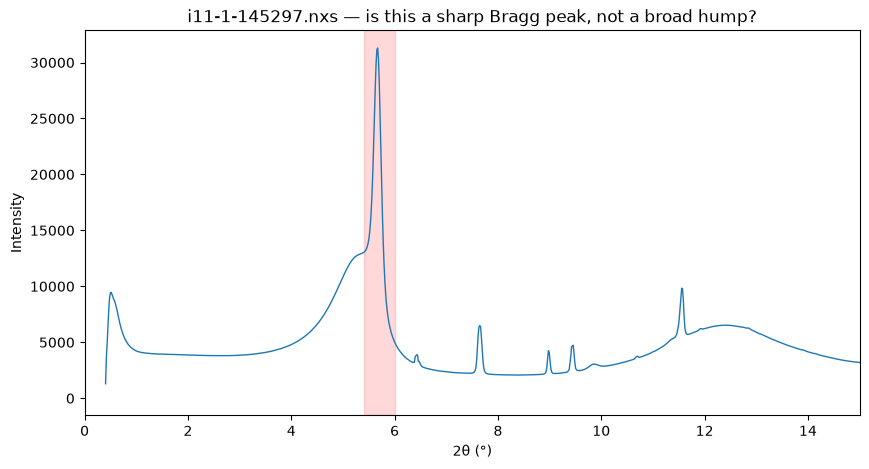

In [33]:
for fname in ["i11-1-145293.nxs", "i11-1-145297.nxs"]:
    stem = os.path.splitext(fname)[0]
    out_path = os.path.join(OUTPUT_DIR, "production", f"{stem}_bg_Water_tri_smooth.nxs")
    corr = _load_pixium_frame(out_path)
    if corr.ndim == 3:
        corr = corr[0]
    tth_i, i_i = ai.integrate1d(corr.astype(np.float32), npt, mask=mask.astype(np.int32), unit="2th_deg")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(tth_i, i_i, lw=1)
    ax.axvspan(5.4, 6.0, alpha=0.15, color="red")
    ax.set_xlim(0, 15)
    ax.set_xlabel("2θ (°)"); ax.set_ylabel("Intensity")
    ax.set_title(f"{fname} — is this a sharp Bragg peak, not a broad hump?")
    plt.show()

In [34]:
for fname in ["145293", "145297", "145298"]:
    fp = [f for f in GLY_AS_FILES if fname in f][0]
    raw = _load_pixium_frame(fp)
    if raw.ndim == 3:
        raw = raw[0]
    print(f"i11-1-{fname}.nxs: raw mean={raw.mean():.1f}  raw max={raw.max():.0f}")
    

i11-1-145293.nxs: raw mean=1282.5  raw max=29721
i11-1-145297.nxs: raw mean=1200.6  raw max=1784065
i11-1-145298.nxs: raw mean=39.9  raw max=59482


In [45]:
from fep_subtraction_2d_i11 import _read_exposure_time

for fname in ["145293", "145297", "145298"]:
    fp = [f for f in GLY_AS_FILES if fname in f][0]
    t = _read_exposure_time(fp)
    print(f"i11-1-{fname}.nxs: real exposure = {t}s")

i11-1-145293.nxs: real exposure = Nones
i11-1-145297.nxs: real exposure = Nones
i11-1-145298.nxs: real exposure = Nones


In [39]:
import h5py

def _read_exposure_time(filepath):
    """Override: static trial files use 'pixium_hdf' as the detector group name."""
    paths = [
        "entry1/instrument/pixium_hdf/count_time",
        "entry/instrument/pixium_hdf/count_time",
        "entry1/instrument/detector/count_time",
        "entry1/instrument/detector/exposure_time",
        "entry/instrument/detector/count_time",
        "entry/instrument/detector/exposure_time",
        "entry1/count_time",
        "entry/count_time",
    ]
    with h5py.File(filepath, "r") as f:
        for p in paths:
            if p in f:
                val = np.squeeze(f[p][()])
                if val.ndim == 0:
                    return float(val)
                return float(np.sum(val))
    return None

In [46]:
tracker_clean[tracker_clean["Collection #(s)"].isin([145293, 145297, 145298])][["Distance (mm)", "Sample code", "Exposure code", "Collection #(s)"]]

,Distance (mm),Sample code,Exposure code,Collection #(s)
31,50,Gly_AS_tri,1000ms,145298
36,50,Gly_AS_tri,long,145297
37,50,Gly_AS_tri,long,145293


---
## Step 6b — Are the persistent peaks/hump genuine FEP?

Compares `FEP_empty`'s own raw integrated pattern (normalised) against the corrected `EtOH_tri` result. If the persistent peaks line up with FEP_empty's own peak positions (printed below the plot), that confirms residual FEP rather than genuine Bragg signal.

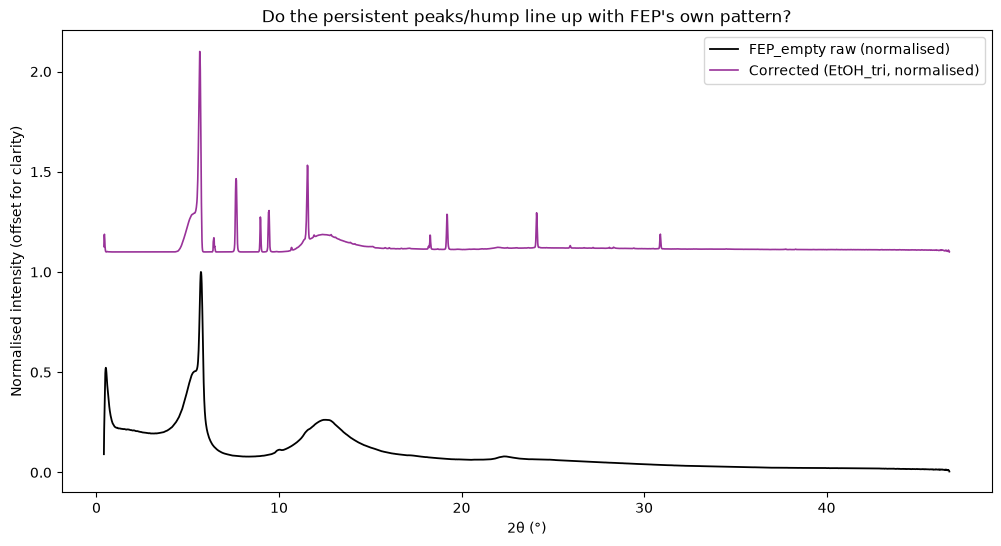

FEP_empty peak positions (2θ°): [ 0.51  1.15  1.49  1.9   2.21  2.54  2.91  3.37  5.39  5.72  7.68  8.04
  8.42  8.78  9.1  10.04 12.48 16.22 16.53 16.95 17.36 17.75 18.09 18.46
 18.85 19.16 19.56 19.88 20.28 20.7  21.06 21.49 22.38 23.   23.33 23.63
 24.02 24.38 24.72 25.07 25.38 25.73 26.06 26.37 26.72 27.06 27.37]


In [40]:
# Uses ai, tth_raw from Step 6 above — must be run after Step 6.

fep_empty_raw = _load_pixium_frame(FEP_EMPTY_FILES_100ms[0])   # or your best single FEP_empty file
if fep_empty_raw.ndim == 3:
    fep_empty_raw = fep_empty_raw[0]

tth_fep, i_fep = ai.integrate1d(fep_empty_raw.astype(np.float32), npt,
                                 mask=mask.astype(np.int32), unit="2th_deg")

# Use EtOH_tri explicitly (rather than relying on leftover loop variables
# from Step 6) so this cell works regardless of run order.
tth_c_etoh, i_c_etoh = ai.integrate1d(
    corrected_results["EtOH_tri"].corrected_frame.astype(np.float32), npt,
    mask=mask.astype(np.int32), unit="2th_deg",
)

# Normalise both to their own max so shapes are comparable regardless of
# absolute intensity/exposure differences
i_fep_norm = i_fep / i_fep.max()
i_corr_norm = i_c_etoh / i_c_etoh.max()

fig, ax = plt.subplots(figsize=(12, 6))

offset = 1.1   # adjust this until the gap looks right

ax.plot(tth_fep, i_fep_norm, lw=1.3, color="black", label="FEP_empty raw (normalised)")
ax.plot(tth_c_etoh, i_corr_norm + offset, lw=1.2, color="purple", alpha=0.8, label="Corrected (EtOH_tri, normalised)")
ax.set_xlabel("2θ (°)"); ax.set_ylabel("Normalised intensity (offset for clarity)")
ax.legend()
ax.set_title("Do the persistent peaks/hump line up with FEP's own pattern?")
plt.show()

# Print the actual peak positions in the FEP_empty pattern for a precise check
from scipy.signal import find_peaks
peaks, _ = find_peaks(i_fep_norm, height=0.05, distance=20)
print("FEP_empty peak positions (2\u03b8\u00b0):", np.round(tth_fep[peaks], 2))


# 6C

In [41]:
from scipy.signal import find_peaks

# Sweep a range of prominence thresholds to see where the noise-driven
# tail peaks (the ~0.38°-spaced ones above 13°) drop out, rather than
# picking one threshold blindly.
for prom in [0.005, 0.01, 0.02, 0.03, 0.05]:
    pk, props = find_peaks(i_fep_norm, prominence=prom, distance=20)
    n_above_13 = int(np.sum(tth_fep[pk] > 13))
    print(f"prominence={prom:<6} -> {len(pk):>3} peaks total, {n_above_13:>3} of them above 13°")

prominence=0.005  ->   4 peaks total,   1 of them above 13°
prominence=0.01   ->   4 peaks total,   1 of them above 13°
prominence=0.02   ->   3 peaks total,   0 of them above 13°
prominence=0.03   ->   3 peaks total,   0 of them above 13°
prominence=0.05   ->   3 peaks total,   0 of them above 13°


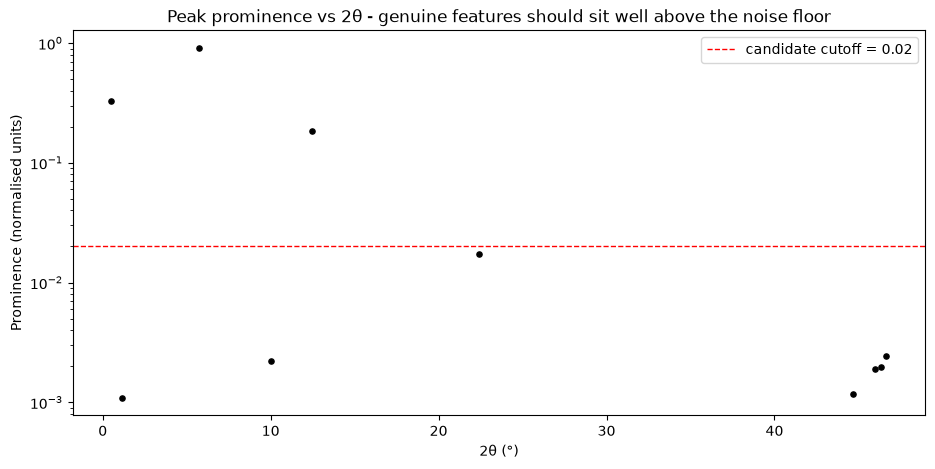

In [42]:
# Plot prominence vs 2θ for a low threshold, to visually pick a sensible
# cutoff (an elbow/gap) rather than guessing.
pk_all, props_all = find_peaks(i_fep_norm, prominence=0.001, distance=20)

fig, ax = plt.subplots(figsize=(11, 5))
ax.scatter(tth_fep[pk_all], props_all["prominences"], s=14, color="black")
ax.set_xlabel("2θ (°)"); ax.set_ylabel("Prominence (normalised units)")
ax.set_yscale("log")
ax.axhline(0.02, color="red", ls="--", lw=1, label="candidate cutoff = 0.02")
ax.legend()
ax.set_title("Peak prominence vs 2θ - genuine features should sit well above the noise floor")
plt.show()

In [43]:
# Final list at the chosen cutoff (adjust PROMINENCE_CUTOFF based on
# where the sweep/plot above showed the tail peaks drop out).
PROMINENCE_CUTOFF = 0.02

peaks_final, props_final = find_peaks(i_fep_norm, prominence=PROMINENCE_CUTOFF, distance=20)
print(f"FEP_empty peak positions (prominence >= {PROMINENCE_CUTOFF}):")
print(np.round(tth_fep[peaks_final], 2))
print("\nProminences:")
print(np.round(props_final['prominences'], 4))

FEP_empty peak positions (prominence >= 0.02):
[ 0.51  5.72 12.48]

Prominences:
[0.3282 0.9091 0.1841]


---
## Step 7 — Record results

In [44]:
print("=" * 60)
print("  STATIC TRIAL BACKGROUND COMPARISON — SUMMARY")
print("=" * 60)
print(f"  Test frame          : {os.path.basename(TEST_FRAME.filepath)}")
print(f"  Beam centre used    : row={cy:.2f}px col={cx:.2f}px")
print(f"  FEP ring radius     : {cfg.fixed_fep_ring_r}px")
print()
print("  Fill in manually from Step 6 output:")
print("  Best background candidate     : _____ (FEP_empty / Water_tri / EtOH_tri)")
print("  FEP peak reduction (winner)   : _____%")
print("  Diffuse residual flatness     : qualitative note here")
print("  Spot signal preserved?        : YES / NO")
print("  Ready to apply to CBZ trial?  : YES / NO — note reasoning")

  STATIC TRIAL BACKGROUND COMPARISON — SUMMARY
  Test frame          : i11-1-145298.nxs
  Beam centre used    : row=1442.20px col=1441.66px
  FEP ring radius     : 191px

  Fill in manually from Step 6 output:
  Best background candidate     : _____ (FEP_empty / Water_tri / EtOH_tri)
  FEP peak reduction (winner)   : _____%
  Diffuse residual flatness     : qualitative note here
  Spot signal preserved?        : YES / NO
  Ready to apply to CBZ trial?  : YES / NO — note reasoning
